# Mixing equation-based and JAX blocks in one model

POUNCE has two ways to hand the solver a nonlinear model, and they are good at
opposite things.

**Equation-based** — `pounce.NlExpr` / `build_nl_problem` (or `read_nl` /
`parse_nl_text` for a `.nl` file). You write algebra; POUNCE tapes it and
differentiates it in Rust with exact reverse-mode AD. The sparsity pattern is
*read off the tape*, so it is exact rather than probed, and evaluation never
crosses back into Python. What it cannot do is call anything: an `NlExpr` tree
has no callback node, so a trained network, a table lookup, or a fitted closure
has nowhere to live.

**JAX** — `pounce.jax.from_jax`. Anything JAX can trace, POUNCE can solve:
gradient, Jacobian, and Lagrangian Hessian all come from `jax.grad` /
`jacrev` / `hessian`. That includes the trained network the equation surface
cannot express. The costs are a Python round trip per evaluation and, unless
you supply the pattern yourself, sparsity detected by random probing.

Real models often want both at once. A flowsheet is algebra except for one
unit; a reactor train is mass balances except for the rate law, which came out
of a fit. **This notebook builds exactly that model** — three CSTRs in series,
balances as equations and kinetics as a fitted network — and shows that mixing
the two surfaces takes about fifty lines of glue and no changes to POUNCE.

The meeting point is `pounce.Problem`. It does not want an `NlProblem` or a
JAX function; it wants *any Python object* carrying the cyipopt method set
(`crates/pounce-py/src/tnlp_bridge.rs`):

```python
def objective(self, x)            -> float
def gradient(self, x)             -> array(n)
def constraints(self, x)          -> array(m)
def jacobian(self, x)             -> array(nnz_jac)
def jacobianstructure(self)       -> (rows, cols)
def hessian(self, x, lam, obj_f)  -> array(nnz_hess)
def hessianstructure(self)        -> (rows, cols)
```

Both surfaces already produce such an object. So the job is not to bridge two
foreign things — it is to *stack* two objects that already speak the same
protocol.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

import pounce
from pounce.jax import from_jax    # `pounce.jax` is imported on demand, not by `import pounce`

jax.config.update("jax_enable_x64", True)   # pounce is a double-precision solver
print("pounce", pounce.__version__, "| jax", jax.__version__)

pounce 0.11.0 | jax 0.10.2


## 1. The model

Three isothermal CSTRs in series, all at one temperature $T$ and all of one
volume $V$ (the design variables). Feed is $q = 10$ L/min of $C_{A0} = 2$
mol/L, and the outlet of the last stage must reach $C_A \le 0.25$ mol/L.

Two kinds of statement describe it:

**Mass balances** — algebra, known exactly, one per stage:

$$q\,(C_{A,i-1} - C_{A,i}) - V r_i = 0, \qquad C_{A,0} \equiv C_{A0}$$

**The rate law** — *not* known as an equation. We have a fitted surrogate:

$$r_i = \widehat{r}(C_{A,i}, T)$$

Writing $r_i$ as its own variable is what makes the split clean: the balances
stay pure algebra referring to $r_i$, and the surrogate gets one residual row
of its own. That is the general recipe — **give the black-box output a
variable and let one constraint row define it**.

The variable vector, $n = 8$:

| slot | meaning |
|---|---|
| `x[0:3]` | $C_{A,1}, C_{A,2}, C_{A,3}$ |
| `x[3:6]` | $r_1, r_2, r_3$ |
| `x[6]`   | $V$ |
| `x[7]`   | $T$ |

In [2]:
N = 3                       # stages
n = 2 * N + 2               # CA(N), r(N), V, T
iCA = slice(0, N)
iR  = slice(N, 2 * N)
iV, iT = 2 * N, 2 * N + 1

q, CA0, T0 = 10.0, 2.0, 320.0          # L/min, mol/L, K (base temperature)
cost_V, cost_T = 0.5, 2.0e-2           # $/L per stage, $/K^2 of heating
CA_target = 0.25                       # mol/L, outlet spec
w_trust = 200.0                        # weight on the surrogate trust penalty

## 2. The surrogate

The premise is that we only ever saw *data*. So: sample a truth model we then
put away, and fit a small tanh network to it with plain JAX. `rate_nn` is the
thing that cannot be written as an `NlExpr` — the whole reason this notebook
exists.

We keep `true_rate` around only to audit the answer in §7.

In [3]:
def true_rate(CA, T):
    """Arrhenius truth model. Used to generate data and, in section 6, to
    audit the optimum. It never enters the optimization problem."""
    return 5.0e5 * np.exp(-5000.0 / T) * CA ** 1.4


rng = np.random.default_rng(0)
CA_s = rng.uniform(0.05, 2.0, 600)
T_s = rng.uniform(300.0, 380.0, 600)
r_s = true_rate(CA_s, T_s)

# Normalize inputs and outputs so the fit is well conditioned.
mu = np.array([1.0, 340.0])
sd = np.array([0.6, 25.0])
r_sd = r_s.std()

Xn = jnp.asarray(np.stack([(CA_s - mu[0]) / sd[0], (T_s - mu[1]) / sd[1]], axis=1))
Yn = jnp.asarray(r_s / r_sd)

H = 16
k1, k2 = jax.random.split(jax.random.PRNGKey(0))
params = [jax.random.normal(k1, (2, H)) * 0.8, jnp.zeros(H),
          jax.random.normal(k2, (H, 1)) * 0.5, jnp.zeros(1)]


def net(p, xn):
    W1, b1, W2, b2 = p
    return (jnp.tanh(xn @ W1 + b1) @ W2 + b2).squeeze(-1)


value_and_grad = jax.jit(jax.value_and_grad(
    lambda p: jnp.mean((net(p, Xn) - Yn) ** 2)))

momentum = [jnp.zeros_like(p) for p in params]
for _ in range(6000):                      # plain momentum SGD; no extra deps
    loss, grads = value_and_grad(params)
    momentum = [0.9 * m + g for m, g in zip(momentum, grads)]
    params = [p - 2e-2 * m for p, m in zip(params, momentum)]


@jax.jit
def rate_nn(CA, T):
    xn = jnp.stack([(CA - mu[0]) / sd[0], (T - mu[1]) / sd[1]], axis=-1)
    return net(params, xn) * r_sd


print(f"fit rmse = {float(jnp.sqrt(loss)) * r_sd:.4f} mol/L/min "
      f"({100 * float(jnp.sqrt(loss)):.1f}% of the rate scale)\n")
print(f"{'CA':>6} {'T':>7} {'surrogate':>11} {'truth':>10}")
for CA, T in [(1.5, 340.0), (0.9, 360.0), (0.25, 360.0)]:
    got = float(rate_nn(jnp.array(CA), jnp.array(T)))
    print(f"{CA:6.2f} {T:7.1f} {got:11.4f} {true_rate(CA, T):10.4f}")

fit rmse = 0.0059 mol/L/min (1.4% of the rate scale)

    CA       T   surrogate      truth
  1.50   340.0      0.3653     0.3621
  0.90   360.0      0.4026     0.4009
  0.25   360.0      0.0626     0.0667


## 3. The equation block

Everything POUNCE can be told exactly: the three balances, plus the objective
(capital cost proportional to total volume, heating cost quadratic in the
temperature rise).

`build_nl_problem` returns an `NlProblem` whose derivatives come off the Rust
tape. Note it is built at the **full** `n = 8` — the block does not know or
care that another block will supply rows later. That is the contract for the
stacker in §5: *every block is a function of the whole `x`*.

In [4]:
v = pounce.NlExpr.vars(n)

CA_in = [pounce.NlExpr.const_(CA0)] + [v[i - 1] for i in range(1, N)]
balances = [q * (CA_in[i] - v[i]) - v[iV] * v[N + i] for i in range(N)]

algebraic_cost = N * cost_V * v[iV] + cost_T * (v[iT] - T0) ** 2

eqn_problem = pounce.build_nl_problem(
    n=n,
    objective=algebraic_cost,
    constraints=balances,
    g_l=[0.0] * N, g_u=[0.0] * N,
)
print(eqn_problem)
print("jacobian_structure nnz:", eqn_problem.jacobian_structure()[0].size)
print("hessian_structure  nnz:", eqn_problem.hessian_structure()[0].size)

NlProblem(n=8, m=3, nnz_jac=11, nnz_hess=4, minimize=true)
jacobian_structure nnz: 11
hessian_structure  nnz: 4


## 4. The JAX block

Two contributions:

* **Three constraint rows**, $r_i - \widehat r(C_{A,i}, T) = 0$ — the surrogate
  wired into the model.
* **One objective term**, a soft penalty that grows as the operating point
  leaves the box the surrogate was fitted on. Optimizing against a surrogate
  without a term like this is how you end up at an optimum that only exists in
  the fit. It is written in the network's own normalized coordinates, which is
  why it belongs to this block rather than the algebraic one.

We write the seven methods out by hand rather than calling `from_jax`, for two
reasons: `from_jax` returns a finished `Problem` (we need the *object*, not the
problem), and writing it out shows there is nothing privileged about what
`from_jax` builds.

**The sparsity patterns are supplied, not probed.** They are known in closed
form here — row $i$ of this block touches only $C_{A,i}$, $r_i$, and $T$ — and
the docs are emphatic that a supplied pattern is both cheaper and safer than a
probed one. It must be a *superset* of the truth; a missing entry is silently
wrong. (If you would rather not derive it by hand, notebook 33 does it from the
jaxpr with `asdex`.)

In [5]:
def rate_residuals(x):
    """r_i - surrogate(CA_i, T), one row per stage."""
    return x[iR] - rate_nn(x[iCA], jnp.full((N,), x[iT]))


def trust_penalty(x):
    """Soft guard keeping the optimizer inside the surrogate's training box.
    Separable in each input, and smooth everywhere (no abs / max kink)."""
    dCA = (x[iCA] - mu[0]) / sd[0]
    dT = (x[iT] - mu[1]) / sd[1]
    return w_trust * (jnp.sum(jnp.exp(2 * (dCA ** 2 - 4.0)))
                      + jnp.exp(2 * (dT ** 2 - 4.0)))


def lagrangian(x, lam, obj_factor):
    return obj_factor * trust_penalty(x) + jnp.dot(lam, rate_residuals(x))


# --- structure, known in closed form --------------------------------------
# Jacobian row i touches CA_i (col i), r_i (col N+i), T (col iT).
_jr = np.repeat(np.arange(N), 3)
_jc = np.concatenate([[i, N + i, iT] for i in range(N)])

# Lagrangian Hessian lower triangle: r enters linearly, the penalty is
# separable, and the surrogate couples each CA_i with T.
_hr = np.concatenate([np.arange(N), np.full(N, iT), [iT]])
_hc = np.concatenate([np.arange(N), np.arange(N), [iT]])


class JaxBlock:
    """The cyipopt method set, backed by JAX AD."""

    m = N

    def __init__(self):
        self._f = jax.jit(trust_penalty)
        self._grad = jax.jit(jax.grad(trust_penalty))
        self._g = jax.jit(rate_residuals)
        self._jac = jax.jit(jax.jacrev(rate_residuals))
        self._hess = jax.jit(jax.hessian(lagrangian))

    def objective(self, x):      return float(self._f(jnp.asarray(x)))
    def gradient(self, x):       return np.asarray(self._grad(jnp.asarray(x)))
    def constraints(self, x):    return np.asarray(self._g(jnp.asarray(x)))
    def jacobianstructure(self): return _jr, _jc
    def hessianstructure(self):  return _hr, _hc

    def jacobian(self, x):
        return np.asarray(self._jac(jnp.asarray(x)))[_jr, _jc]

    def hessian(self, x, lam, obj_factor):
        Hs = self._hess(jnp.asarray(x), jnp.asarray(lam), float(obj_factor))
        return np.asarray(Hs)[_hr, _hc]


jax_block = JaxBlock()
print("jax block: m =", jax_block.m,
      "| nnz jac =", _jr.size, "| nnz hess =", _hr.size)

jax block: m = 3 | nnz jac = 9 | nnz hess = 7


## 5. The stacker

Two blocks, both functions of the same `x`, both already speaking the cyipopt
protocol. Stacking them is four rules:

| piece | rule |
|---|---|
| objective, gradient | **add** — both blocks contribute to one $f$ |
| constraints | **stack** — blocks own disjoint row ranges |
| Jacobian | **concatenate**, with each block's rows offset by where it starts |
| Hessian | **concatenate** — see below |

The Hessian is the only one that needs an argument. Both blocks touch the same
variables, so their lower triangles *overlap*: here both declare an entry at
$(T, T)$. Concatenating the two structure arrays therefore declares that entry
twice.

That is fine, and it is the documented contract rather than an accident.
POUNCE's triplet→CSR converter is a port of Ipopt's, and
`crates/pounce-linalg/src/triplet_convert.rs` states it outright: matrices
"arrive in triplet (COO) form with possibly repeated `(row, col)` entries" and
are compressed **"with repeated entries summed."** A duplicated entry is
exactly what we want — the two blocks' second derivatives *should* add.

One caveat on the naming: `NlProblem` spells its structure methods
`jacobian_structure` / `hessian_structure`, while the bridge wants cyipopt's
run-together `jacobianstructure` / `hessianstructure`. That is the entire
reason `NlBlock` below exists — six lines of renaming, nothing more.

So the whole stacker is:

In [6]:
class NlBlock:
    """cyipopt-shaped view of an NlProblem (renames the two structure
    methods; every other method already matches)."""

    def __init__(self, p):
        self.p = p
        self.m = p.m

    def objective(self, x):      return self.p.objective(x)
    def gradient(self, x):       return np.asarray(self.p.gradient(x))
    def constraints(self, x):    return np.asarray(self.p.constraints(x))
    def jacobianstructure(self): return self.p.jacobian_structure()
    def jacobian(self, x):       return np.asarray(self.p.jacobian(x))
    def hessianstructure(self):  return self.p.hessian_structure()

    def hessian(self, x, lam, obj_factor):
        return np.asarray(self.p.hessian(x, lam if self.m else None, obj_factor))


class Mixed:
    """Stack cyipopt-shaped blocks defined over a shared x into one
    problem_obj. Objectives add; constraint rows concatenate."""

    def __init__(self, blocks, n):
        self.blocks, self.n = list(blocks), n
        self.m_each = [b.m for b in self.blocks]
        self.m = sum(self.m_each)
        self.offsets = np.cumsum([0] + self.m_each)[:-1]

        jr, jc, hr, hc = [], [], [], []
        for b, off in zip(self.blocks, self.offsets):
            r, c = b.jacobianstructure()
            jr.append(np.asarray(r, np.int64) + off)      # rows are disjoint
            jc.append(np.asarray(c, np.int64))
            r, c = b.hessianstructure()
            r, c = np.asarray(r, np.int64), np.asarray(c, np.int64)
            hr.append(np.maximum(r, c))                   # fold to lower
            hc.append(np.minimum(r, c))
        self._jac_s = (np.concatenate(jr), np.concatenate(jc))
        self._hes_s = (np.concatenate(hr), np.concatenate(hc))

    def objective(self, x):
        return float(sum(b.objective(x) for b in self.blocks))

    def gradient(self, x):
        return sum(np.asarray(b.gradient(x), float) for b in self.blocks)

    def constraints(self, x):
        return np.concatenate([np.asarray(b.constraints(x), float)
                               for b in self.blocks])

    def jacobianstructure(self):
        return self._jac_s

    def jacobian(self, x):
        return np.concatenate([np.asarray(b.jacobian(x), float)
                               for b in self.blocks])

    def hessianstructure(self):
        return self._hes_s

    def hessian(self, x, lam, obj_factor):
        lam = np.asarray(lam, float)
        return np.concatenate([
            np.asarray(b.hessian(x, lam[o:o + mi], obj_factor), float)
            for b, o, mi in zip(self.blocks, self.offsets, self.m_each)])


mixed = Mixed([NlBlock(eqn_problem), jax_block], n=n)
print("mixed problem: n =", n, " m =", mixed.m)
print("declared nnz  jac =", mixed.jacobianstructure()[0].size,
      " hess =", mixed.hessianstructure()[0].size)

mixed problem: n = 8  m = 6
declared nnz  jac = 20  hess = 11


## 6. Solve it

Bounds carry the design limits and the outlet spec: `CA[2] <= 0.25` is the
conversion requirement, and `T <= 380` keeps the temperature inside the range
the surrogate saw. Both blocks' rows are equalities, so `cl = cu = 0`.

In [7]:
lb = [0.01] * N + [0.0] * N + [1.0, 300.0]
ub = [2.0] * (N - 1) + [CA_target] + [50.0] * N + [500.0, 380.0]
x0 = [1.2, 0.7, 0.25] + [0.5, 0.3, 0.15] + [30.0, 350.0]

prob = pounce.Problem(
    n=n, m=mixed.m, problem_obj=mixed,
    lb=lb, ub=ub,
    cl=[0.0] * mixed.m, cu=[0.0] * mixed.m,
)
prob.add_option("print_level", 0)
prob.add_option("tol", 1e-10)

x, info = prob.solve(x0=x0)
x = np.asarray(x)

print(info["status_msg"], " objective =", round(info["obj_val"], 6), "$/min\n")
print(f"  V = {x[iV]:8.3f} L per stage   (tau = {x[iV] / q:.2f} min)")
print(f"  T = {x[iT]:8.3f} K\n")
print(f"{'stage':>6} {'CA (mol/L)':>12} {'rate':>10}")
for i in range(N):
    print(f"{i + 1:6d} {x[i]:12.4f} {x[N + i]:10.4f}")
print(f"\n  capital {N * cost_V * x[iV]:7.3f}   heating "
      f"{cost_T * (x[iT] - T0) ** 2:7.3f}   trust "
      f"{float(trust_penalty(jnp.asarray(x))):7.3f}")

Solve_Succeeded  objective = 78.519981 $/min

  V =   29.547 L per stage   (tau = 2.95 min)
  T =  359.977 K

 stage   CA (mol/L)       rate
     1       0.8684     0.3830
     2       0.4347     0.1468
     3       0.2500     0.0625



  capital  44.320   heating  31.962   trust   2.237


## 7. Is it right?

Two independent checks, because "it converged" is not evidence.

**Against an all-JAX twin.** Write the *same* model entirely in JAX — balances
included — and hand it to `from_jax`. The twin re-derives the balances and
every derivative through JAX, sharing nothing with the mixed build but the
surrogate and the cost constants, so agreement means the stacker's index
bookkeeping is right. We compare the optimum, and also the gradient and the full Lagrangian
Hessian at an off-solution probe point, which is where a scatter bug would
show even if the solve happened to land in the same place.

**Against the truth model.** Substitute `true_rate` into the balances at the
converged point. The mixed model is *exactly* consistent with the surrogate,
so what is left is the surrogate's own error — a statement about the fit, not
about the solver.

In [8]:
def f_all_jax(x):
    return N * cost_V * x[iV] + cost_T * (x[iT] - T0) ** 2 + trust_penalty(x)


def g_all_jax(x):
    CAin = jnp.concatenate([jnp.array([CA0]), x[iCA][:N - 1]])
    return jnp.concatenate([q * (CAin - x[iCA]) - x[iV] * x[iR],
                            rate_residuals(x)])


reference = from_jax(
    f_all_jax, g_all_jax, n=n, m=2 * N, lb=lb, ub=ub,
    cl=[0.0] * (2 * N), cu=[0.0] * (2 * N),
)
reference.add_option("print_level", 0)
reference.add_option("tol", 1e-10)
x_ref, info_ref = reference.solve(x0=x0)
x_ref = np.asarray(x_ref)

print("vs all-JAX twin")
print("  max |dx*|      ", f"{np.max(np.abs(x - x_ref)):.3e}")
print("  |df*|          ", f"{abs(info['obj_val'] - info_ref['obj_val']):.3e}")

# Derivatives at an off-solution probe point.
xp = np.array([1.1, 0.6, 0.3, 0.4, 0.2, 0.1, 25.0, 355.0])
lp = np.array([0.3, -0.2, 0.5, 1.1, -0.7, 0.4])

g_mix = mixed.gradient(xp)
g_ref = np.asarray(jax.grad(f_all_jax)(jnp.asarray(xp)))
print("  max |dgrad|    ", f"{np.max(np.abs(g_mix - g_ref)):.3e}")

Hm = np.zeros((n, n))
hr, hc = mixed.hessianstructure()
np.add.at(Hm, (hr, hc), mixed.hessian(xp, lp, 1.0))   # duplicates sum, as the solver does
Hm = Hm + Hm.T - np.diag(np.diag(Hm))
Hr = np.asarray(jax.hessian(
    lambda z: f_all_jax(z) + jnp.dot(jnp.asarray(lp), g_all_jax(z)))(jnp.asarray(xp)))
print("  max |dHess|    ", f"{np.max(np.abs(Hm - Hr)):.3e}")

CA_in_star = np.concatenate([[CA0], x[iCA][:N - 1]])
resid = q * (CA_in_star - x[iCA]) - x[iV] * true_rate(x[iCA], x[iT])
print("\nvs the truth model (surrogate error, not solver error)")
print("  balance residual", np.array2string(resid, precision=4))
print("  as % of q*dCA   ",
      np.array2string(100 * np.abs(resid) / (q * (CA_in_star - x[iCA])), precision=2))

vs all-JAX twin
  max |dx*|       1.776e-14
  |df*|           1.421e-14


  max |dgrad|     6.217e-15


  max |dHess|     5.684e-14

vs the truth model (surrogate error, not solver error)
  balance residual [ 0.0594  0.064  -0.1223]
  as % of q*dCA    [0.52 1.48 6.62]


Machine precision against the twin, and residuals against the truth model at
the ~1% level the fit itself carries. Note the second number is *not* a
verification of the mixing — it is the honest cost of having used a surrogate
at all, and it would be the same for the all-JAX build.

## 8. Sparsity survives the mix

Each block declares its own structure and the stacker keeps both, so the mixed
model is as sparse as its parts. The one thing to know is that concatenation
declares the *overlap* twice — `(T, T)` here — so the declared triplet count is
slightly above the true number of distinct entries. The converter coalesces
them, so this costs a little memory in the triplet array and nothing in the
factorization.

Jacobian :  20 nnz of 48 dense
Hessian  :  11 declared,  10 distinct, of 36 dense lower triangle
declared by both blocks: [(7, 7)]


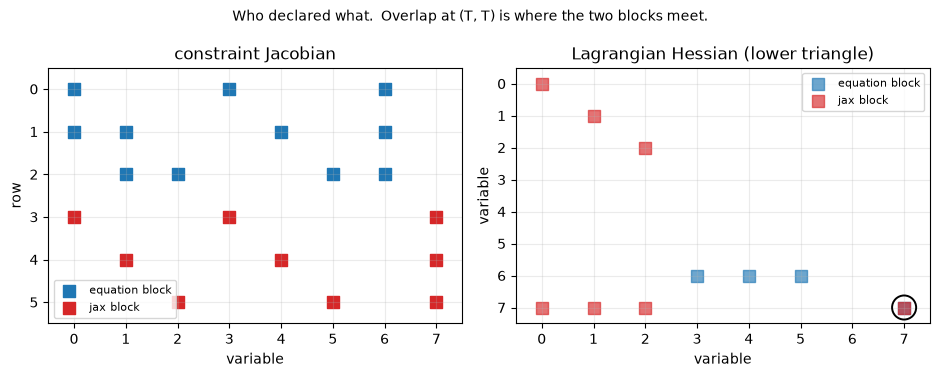

In [9]:
hr, hc = mixed.hessianstructure()
distinct = np.unique(hr * n + hc).size
print(f"Jacobian : {mixed.jacobianstructure()[0].size:3d} nnz "
      f"of {mixed.m * n} dense")
print(f"Hessian  : {hr.size:3d} declared, {distinct:3d} distinct, "
      f"of {n * (n + 1) // 2} dense lower triangle")
dup = [(int(r), int(c)) for r, c in zip(hr, hc)
       if np.sum((hr == r) & (hc == c)) > 1]
print("declared by both blocks:", sorted(set(dup)))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
colors = {0: ("#1f77b4", "equation block"), 1: ("#d62728", "jax block")}

for bi, (b, off) in enumerate(zip(mixed.blocks, mixed.offsets)):
    r, c = b.jacobianstructure()
    axes[0].scatter(np.asarray(c), np.asarray(r) + off, s=70, marker="s",
                    color=colors[bi][0], label=colors[bi][1])
    r, c = b.hessianstructure()
    r, c = np.asarray(r), np.asarray(c)
    axes[1].scatter(np.minimum(r, c), np.maximum(r, c), s=70, marker="s",
                    color=colors[bi][0], alpha=0.65, label=colors[bi][1])

for r, c in sorted(set(dup)):                       # ring the shared entries
    axes[1].scatter([c], [r], s=300, facecolors="none", edgecolors="k",
                    linewidths=1.4, zorder=5)

axes[0].set(title="constraint Jacobian", xlabel="variable", ylabel="row",
            xlim=(-0.5, n - 0.5), ylim=(mixed.m - 0.5, -0.5))
axes[1].set(title="Lagrangian Hessian (lower triangle)", xlabel="variable",
            ylabel="variable", xlim=(-0.5, n - 0.5), ylim=(n - 0.5, -0.5))
for ax in axes:
    ax.set_xticks(range(n)); ax.grid(alpha=0.25); ax.legend(fontsize=8)
axes[0].set_yticks(range(mixed.m)); axes[1].set_yticks(range(n))
fig.suptitle("Who declared what.  Overlap at (T, T) is where the two blocks meet.",
             fontsize=10)
fig.tight_layout()
plt.show()

## 9. The sensitivity layer comes along free

`pounce.Solver` takes a `Problem`, not an `NlProblem` — so everything in
`pounce.sensitivity` works on a mixed model with no extra plumbing. Here we ask
a question that spans both blocks: **how does the design move if the feed rate
changes?**

$q$ appears only in the equation block's balance rows, so perturbing those rows'
right-hand sides is a feed-rate perturbation. The answer necessarily flows
through the JAX block, since the rates must re-satisfy the surrogate. We check
the parametric step against a re-solve at the perturbed model.

In [10]:
solver = pounce.Solver(prob)
xs, _ = solver.solve(x0=x0)
xs = np.asarray(xs)
print("converged:", solver.converged, "| KKT dim:", solver.kkt_dim)

# d(q) = +0.1 L/min scales each balance row's constant term by dq*(CA_in - CA).
dq = 0.1
rhs = [-dq * (CA_in_star[i] - xs[i]) for i in range(N)]
step = np.asarray(solver.parametric_step(list(range(N)), rhs))[:n]

perturbed = Mixed([NlBlock(pounce.build_nl_problem(
    n=n,
    objective=algebraic_cost,
    constraints=[(q + dq) * (CA_in[i] - v[i]) - v[iV] * v[N + i] for i in range(N)],
    g_l=[0.0] * N, g_u=[0.0] * N)), JaxBlock()], n=n)
p2 = pounce.Problem(n=n, m=perturbed.m, problem_obj=perturbed, lb=lb, ub=ub,
                    cl=[0.0] * perturbed.m, cu=[0.0] * perturbed.m)
p2.add_option("print_level", 0)
p2.add_option("tol", 1e-10)
x2, _ = p2.solve(x0=list(xs))
truth = np.asarray(x2) - xs

names = [f"CA{i+1}" for i in range(N)] + [f"r{i+1}" for i in range(N)] + ["V", "T"]
print(f"\n{'':6}{'sens step':>12}{'re-solve':>12}")
for k, nm in enumerate(names):
    print(f"{nm:6}{step[k]:12.5f}{truth[k]:12.5f}")

converged: True | KKT dim: 30



         sens step    re-solve
CA1       -0.00000     0.00001
CA2        0.00002     0.00002
CA3        0.00000     0.00000
r1         0.00280     0.00280
r2         0.00107     0.00107
r3         0.00046     0.00046
V          0.07912     0.07910
T          0.19915     0.19763


The parametric step reproduces the re-solve, and it did so from one back-solve
against the factor already in hand rather than a second optimization.

Read the column: the concentration profile barely moves — it is pinned by the
outlet spec — and the extra feed is absorbed almost entirely by $V$ and $T$.
$T$ is the interesting one. **The balance rows we perturbed do not mention
$T$ at all**; it appears only in the JAX block's surrogate rows. It moves
because the KKT system carries the coupling across the block boundary. That is
the whole point of mixing rather than solving the two halves separately, and
it is why the sensitivity layer had to see one problem rather than two.

## 10. When *not* to do this

Stacking blocks is the right tool when both halves are cheap and
differentiable. Three neighbouring situations want a different one.

**The non-equation half is expensive or has no usable derivatives.** That is
glass box / black box, and it has a dedicated method: `pounce.trf_minimize`
(notebook 29, `docs/src/trf.md`). It builds a corrected surrogate inside a
trust region and converges to the *true* model's optimum while calling it a
handful of times. Fitting a surrogate once and optimizing it — which is what
this notebook's model does, deliberately — can converge to a local *maximum*
of the real problem; §7's truth-model check is the reason we measured rather
than assumed.

**You want to differentiate through the solve.** `pounce.jax.solve` and
`JaxProblem` wrap the solve in a `custom_vjp`, but they need `f(x, p)` and
`g(x, p)` fully JAX-traced, so a mixed problem cannot use them directly. The
machinery underneath is available though: the backward is an implicit-function
back-solve on the KKT system, and `Solver.kkt_solve` reaches the same held
factor §9's `parametric_step` used — on the mixed problem, unchanged. A
hand-rolled `custom_vjp` over it is the route.

**Your algebra lives in Pyomo.** `pyomo-pounce` writes a `.nl` file and runs
the `pounce` binary, so no Python callback can ride that path. The way to put a
callback inside a `.nl` model is an AMPL *imported function*
(`crates/pounce-nl/src/nl_external.rs`), which POUNCE supports through the
`funcadd_ASL` ABI and `AMPLFUNC` — but that means compiling a shared library,
not passing a Python object.

And one limit with no workaround: **an `NlExpr` tree has no callback node.**
`build_nl_problem` has nowhere to put the F-segment declarations that would
bind one (`docs/src/python.md`). Mixing happens between blocks, never inside a
single expression — which is why the recipe in §1 is to give the black box's
output its own variable and its own row.

## Summary

* `pounce.Problem` accepts any object with the seven cyipopt methods, and both
  model surfaces already produce one.
* Objectives add, constraint rows stack, Jacobian rows offset, Hessian triplets
  concatenate — repeated entries are summed by the converter, by contract.
* `NlProblem` needs a six-line rename (`jacobian_structure` →
  `jacobianstructure`) and nothing else.
* Give each block's structure explicitly when you know it; the mixed model is
  as sparse as its parts.
* `pounce.Solver` and the whole sensitivity layer work on the result unchanged.